# 📊 Statistical Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import norm, poisson, shapiro, kstest
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.2f}'.format)

df = pd.read_csv('clean_sales.csv', parse_dates=['InvoiceDate'])
df.shape

(392692, 15)

### Revenue statistics

In [15]:
rev = df['Revenue']

stats_dict = {
    'Mean':rev.mean(),
    'Median':rev.median(),
    'Std':rev.std(),
    'Minimum':rev.min(),
    'Maximum':rev.max(),
    'Percentile 25%':rev.quantile(0.25),
    'Percentile 75%':rev.quantile(0.75),
    'Percentile 95%':rev.quantile(0.95),
    'Percentile 99%':rev.quantile(0.99),
    'Skew':rev.skew(),
    'Kurt':rev.kurtosis()
}

print('Revenue per line item')
for k, v in stats_dict.items():
    print(f'{k:<30} £{v:>10.2f}')

print(f'\nmean/median ratio: {rev.mean()/rev.median():.1f}x')

Revenue per line item
Mean                           £     22.63
Median                         £     12.45
Std                            £    311.10
Minimum                        £      0.00
Maximum                        £ 168469.60
Percentile 25%                 £      4.95
Percentile 75%                 £     19.80
Percentile 95%                 £     67.50
Percentile 99%                 £    203.52
Skew                           £    448.52
Kurt                           £ 229148.86

mean/median ratio: 1.8x


### Revenue distribution

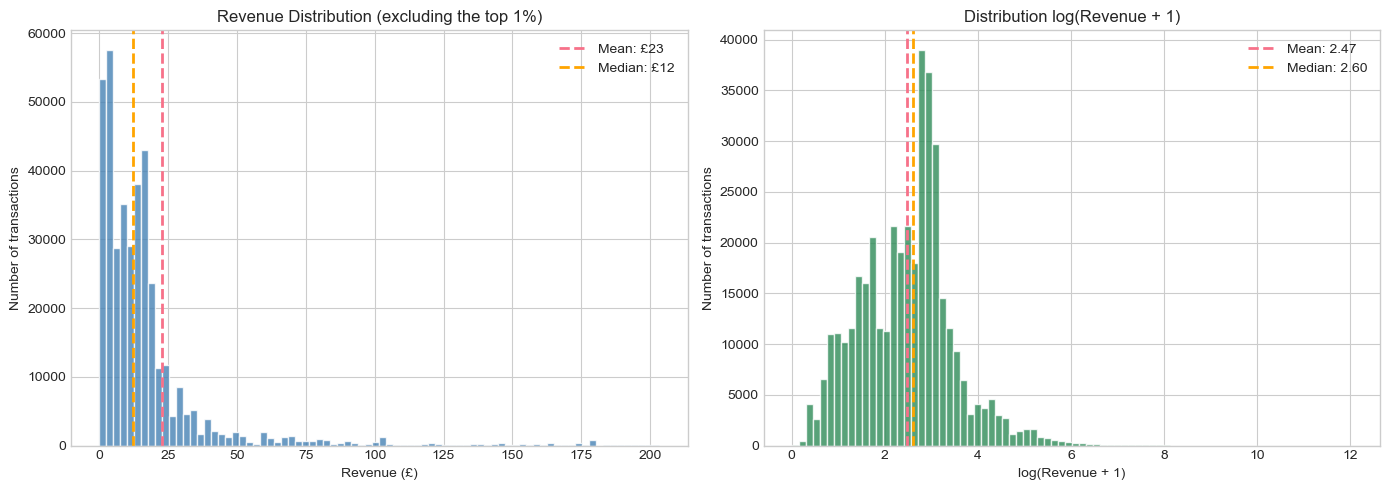

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

#raw distrib. as it is ax0
axes[0].hist(rev[rev < rev.quantile(0.99)], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(rev.mean(), linewidth=2, linestyle='--', label=f'Mean: £{rev.mean():.0f}')
axes[0].axvline(rev.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: £{rev.median():.0f}')
axes[0].set_title('Revenue Distribution (excluding the top 1%)')
axes[0].set_xlabel('Revenue (£)')
axes[0].set_ylabel('Number of transactions')
axes[0].legend()

#log transformed
log_rev = np.log1p(rev)
axes[1].hist(log_rev, bins=80, color='seagreen', edgecolor='white', alpha=0.8)
axes[1].axvline(log_rev.mean(), linestyle='--', linewidth=2, label=f'Mean: {log_rev.mean():.2f}')
axes[1].axvline(log_rev.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {log_rev.median():.2f}')
axes[1].set_title('Distribution log(Revenue + 1)')
axes[1].set_xlabel('log(Revenue + 1)')
axes[1].set_ylabel('Number of transactions')
axes[1].legend()

plt.tight_layout()
plt.show()

### IQR

In [46]:
Q1 = rev.quantile(0.25)
Q3 = rev.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(rev < lower_bound) | (rev > upper_bound)]

print(f'Q1 (25%):        £{Q1:>10.2f}')
print(f'Q3 (75%):        £{Q3:>10.2f}')
print(f'IQR:             £{IQR:>10.2f}')
print(f'\nOutliers found:  {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)')
print(f'Max. outlier:    £{outliers["Revenue"].max():,.2f}')
print("=" * 30)
print(outliers.nlargest(5, 'Revenue')[['InvoiceNo','Description','Quantity','UnitPrice','Revenue','Country']])




Q1 (25%):        £      4.95
Q3 (75%):        £     19.80
IQR:             £     14.85

Outliers found:  31,231 (8.0%)
Max. outlier:    £168,469.60
        InvoiceNo                          Description  Quantity  UnitPrice  \
392226     581483          PAPER CRAFT , LITTLE BIRDIE     80995       2.08   
36521      541431       MEDIUM CERAMIC TOP STORAGE JAR     74215       1.04   
153588     556444       PICNIC BASKET WICKER 60 PIECES        60     649.50   
116868     551697                              POSTAGE         1    8142.75   
246041     567423  SET OF TEA COFFEE SUGAR TINS PANTRY      1412       5.06   

         Revenue         Country  
392226 168469.60  United Kingdom  
36521   77183.60  United Kingdom  
153588  38970.00  United Kingdom  
116868   8142.75  United Kingdom  
246041   7144.72  United Kingdom  


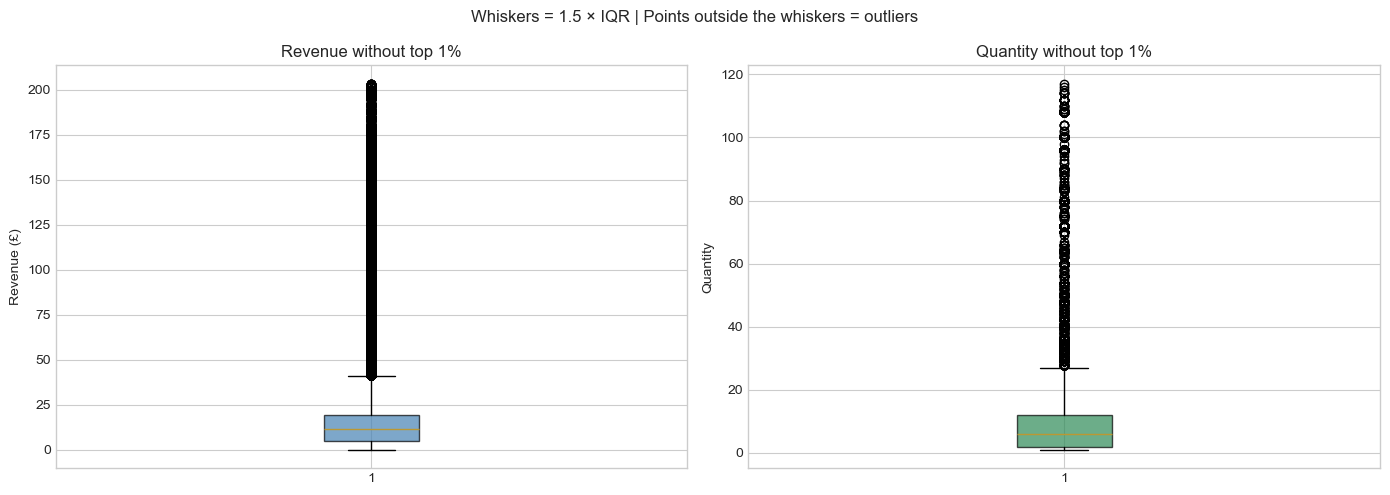

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].boxplot(rev[rev < rev.quantile(0.99)], patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[0].set_title('Revenue without top 1%')
axes[0].set_ylabel('Revenue (£)')

qty = df['Quantity']
axes[1].boxplot(qty[qty < qty.quantile(0.99)], patch_artist=True, boxprops=dict(facecolor='seagreen', alpha=0.7))
axes[1].set_title('Quantity without top 1%')
axes[1].set_ylabel('Quantity')

plt.suptitle('Whiskers = 1.5 × IQR | Points outside the whiskers = outliers', fontsize=12)
plt.tight_layout()

plt.show()

### Shapiro-Wilk test for norm. distribution

In [67]:
sample = rev.sample(3000, random_state=42)
log_sample = np.log1p(sample)

stat_raw, p_raw = shapiro(sample)
stat_log, p_log = shapiro(log_sample)

print('Revenue raw:')
print(f'statistic = {stat_raw:.4f}, p-value = {p_raw:.5f}')

print(f'\nlog(Revenue+1):')
print(f'statistic = {stat_log:.4f}, p-value = {p_log:.5f}')

Revenue raw:
statistic = 0.1976, p-value = 0.00000

log(Revenue+1):
statistic = 0.9787, p-value = 0.00000


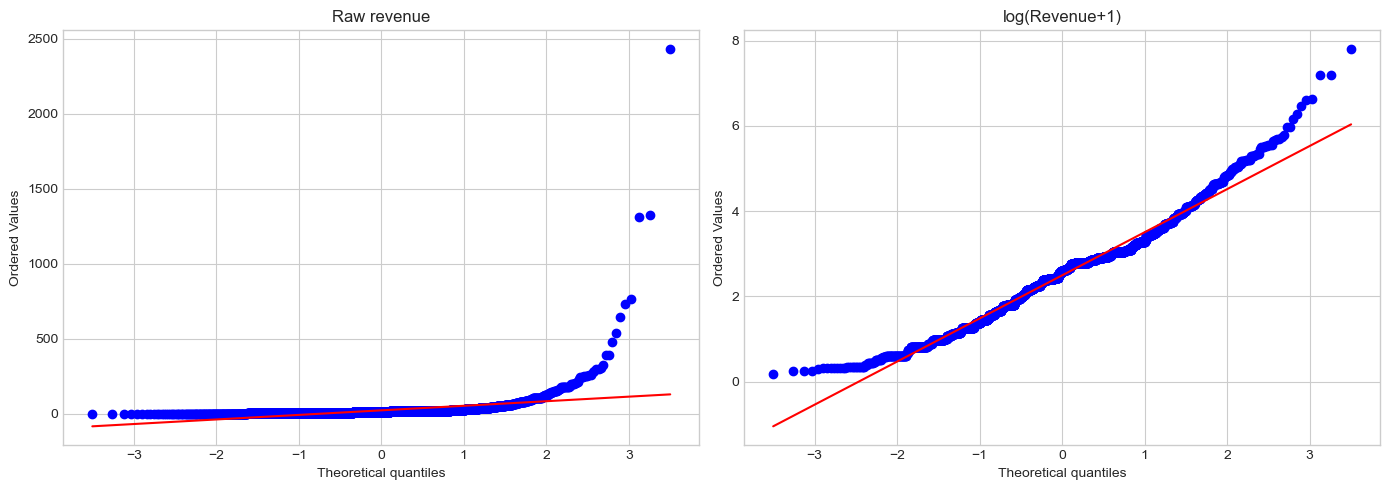

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

stats.probplot(sample, dist='norm', plot=axes[0])
axes[0].set_title('Raw revenue')

stats.probplot(log_sample, dist='norm', plot=axes[1])
axes[1].set_title('log(Revenue+1)')
plt.tight_layout()
plt.show()

### Confidence Intervals

In [85]:
n = len(rev)
mean = rev.mean()
se = stats.sem(rev)

ci_90 = stats.t.interval(0.90, df=n-1, loc=mean, scale=se)
ci_95 = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
ci_99 = stats.t.interval(0.99, df=n-1, loc=mean, scale=se)

print(f'Sample size:     {n:,}')
print(f'Mean:            £{mean:.4f}')
print(f'Std. error (SE): £{se:.4f}\n')

print(f'90% CI: from £{ci_90[0]:.4f} to £{ci_90[1]:.4f}')
print(f'95% CI: from £{ci_95[0]:.4f} to £{ci_95[1]:.4f}')
print(f'99% CI: from £{ci_99[0]:.4f} to £{ci_99[1]:.4f}')

Sample size:     392,692
Mean:            £22.6315
Std. error (SE): £0.4964

90% CI: from £21.8149 to £23.4481
95% CI: from £21.6585 to £23.6045
99% CI: from £21.3527 to £23.9103


BOOTSTRAP 95% CI: from £18.4824 to £27.9932


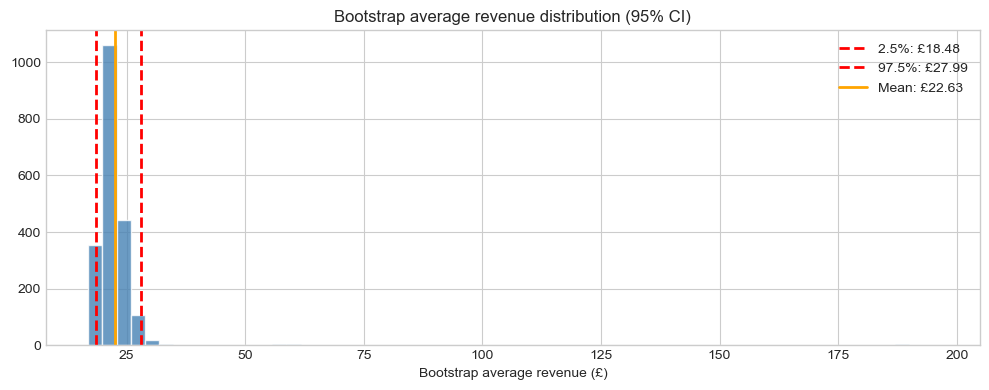

In [93]:
np.random.seed(42)
n_bootstrap = 2000
bootstrap_means = [
    rev.sample(n=1000, replace=True).mean() for _ in range(n_bootstrap)
]

boot_ci = np.percentile(bootstrap_means, [2.5, 97.5])
print(f'BOOTSTRAP 95% CI: from £{boot_ci[0]:.4f} to £{boot_ci[1]:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(bootstrap_means, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(boot_ci[0], color='red', linestyle='--', linewidth=2, label=f'2.5%: £{boot_ci[0]:.2f}')
ax.axvline(boot_ci[1], color='red', linestyle='--', linewidth=2, label=f'97.5%: £{boot_ci[1]:.2f}')
ax.axvline(mean, color='orange', linestyle='-', linewidth=2, label=f'Mean: £{mean:.2f}')
ax.set_xlabel('Bootstrap average revenue (£)')
ax.set_title('Bootstrap average revenue distribution (95% CI)', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

### Time and date sales EDA

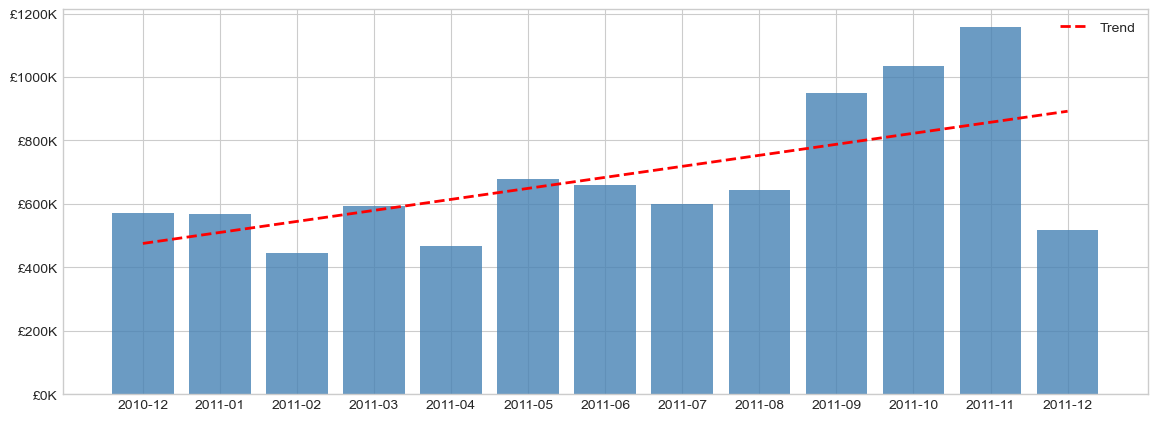

Peak of sales: 2011-11 — £1,156,206


In [112]:
monthly = df.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(monthly['Period'], monthly['Revenue'], alpha=0.8, color='steelblue')

x_num = np.arange(len(monthly))
z = np.polyfit(x_num, monthly['Revenue'], 1)
p = np.poly1d(z)
ax.plot(monthly['Period'], p(x_num), 'r--', linewidth=2, label='Trend')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

ax.legend()
plt.show()

peak = monthly.loc[monthly['Revenue'].idxmax()]
print(f'Peak of sales: {peak["Period"]} — £{peak["Revenue"]:,.0f}')

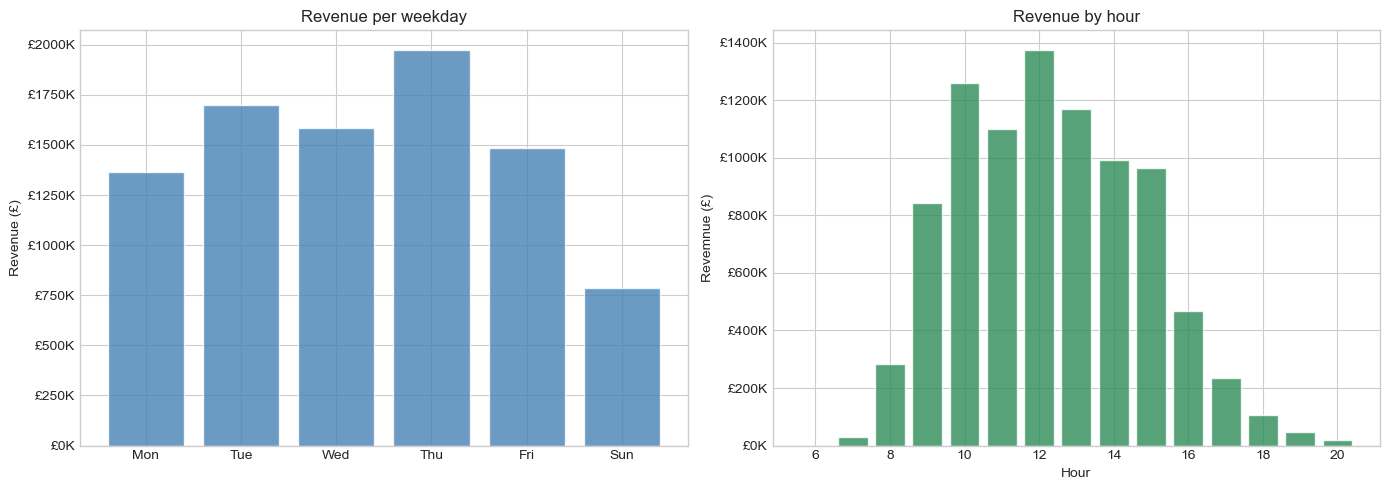

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# По дням недели
days_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
by_day = df.groupby('DayOfWeek')['Revenue'].sum()
by_day.index = [days_map[i] for i in by_day.index]
axes[0].bar(by_day.index, by_day.values, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Revenue per weekday')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

by_hour = df.groupby('Hour')['Revenue'].sum()
axes[1].bar(by_hour.index, by_hour.values, color='seagreen', alpha=0.8, edgecolor='white')
axes[1].set_title('Revenue by hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Revemnue (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.tight_layout()
plt.show()


UK share in revenue: 82.0%


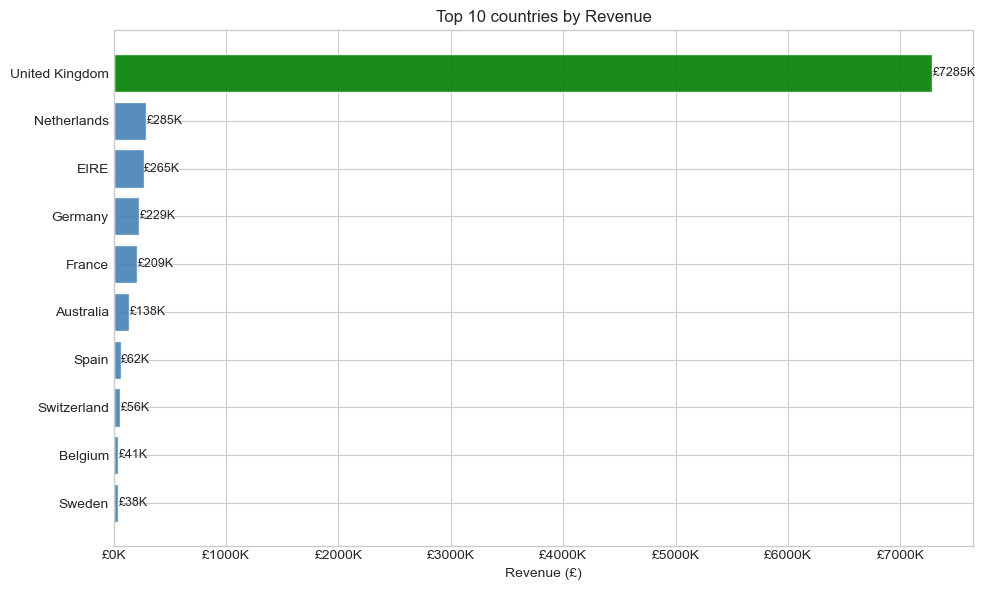

In [138]:
top_countries = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue'] * 9 + ['green']  
bars = ax.barh(top_countries.index, top_countries.values, color=colors, edgecolor='white', alpha=0.9)

for bar, val in zip(bars, top_countries.values):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'£{val/1000:.0f}K', va='center', fontsize=9)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('Top 10 countries by Revenue')
ax.set_xlabel('Revenue (£)')
uk_share = df[df['Country']=='United Kingdom']['Revenue'].sum() / df['Revenue'].sum() * 100
print(f'UK share in revenue: {uk_share:.1f}%')


plt.tight_layout()
plt.show()

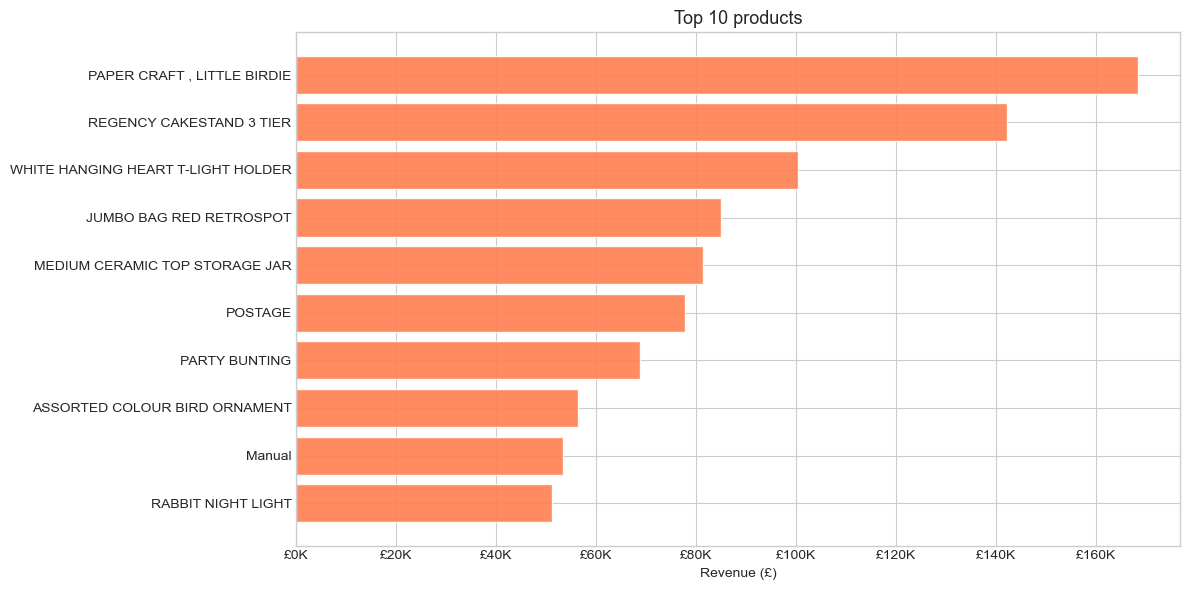

In [139]:
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_products.index[::-1], top_products.values[::-1], color='coral', edgecolor='white', alpha=0.9)
ax.set_xlabel('Revenue (£)')
ax.set_title('Top 10 products', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('top_products.png', dpi=150, bbox_inches='tight')
plt.show()